# Human Activity Recognition — Research Notebook

Course project: identify human activities (walking, running, stairs up/down, standing
still, or an unrecognized activity) from smartphone accelerometer data collected with
the Phyphox app ("Acceleration with g" sensor).

This notebook covers the full research pipeline:
1. Load the raw recordings and inspect them
2. Resample to a uniform rate
3. Window the signal and extract features
4. Visualize feature separability
5. Cluster activities with k-means
6. Classify activities — a baseline using only algorithms taught in the course
   (from-scratch ID3 decision tree, Naive Bayes), and an improved version (Random Forest)
7. Forecast future signal behavior with Gaussian Process regression
8. Persist the trained artifacts used by `02_inference_notebook.ipynb`

All data-processing/model code lives in `har_common.py` so the exact same logic runs
here and in the inference notebook.

**Data note:** training data lives in `activities_measurments/` — currently one
5-minute recording per activity, collected by one team member. The loader
automatically picks up additional recordings from teammates (e.g. `walking_2.csv`)
once added, with no code changes needed — just re-run this notebook.


In [1]:
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import NMF
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, silhouette_score
from sklearn.exceptions import ConvergenceWarning

import har_common as hc
from decision_tree import id3, predict as dt_predict
from naive_bayes import NaiveBayes

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42


## 1. Load raw recordings


In [2]:
recordings = hc.load_activity_files()
for activity, recs in recordings.items():
    for i, df in enumerate(recs):
        duration = df["time"].iloc[-1] - df["time"].iloc[0]
        rate = len(df) / duration
        print(f"{activity:12s} file {i}: {duration:6.1f}s, ~{rate:6.1f} Hz, {len(df)} samples")


walking      file 0:  300.0s, ~ 478.7 Hz, 143618 samples
running      file 0:  300.0s, ~ 478.7 Hz, 143618 samples
stairs_up    file 0:  300.0s, ~ 478.7 Hz, 143618 samples
stairs_down  file 0:  300.0s, ~ 478.7 Hz, 143618 samples
still        file 0:  300.0s, ~ 478.7 Hz, 143618 samples


### Raw signal preview (first 10 seconds)


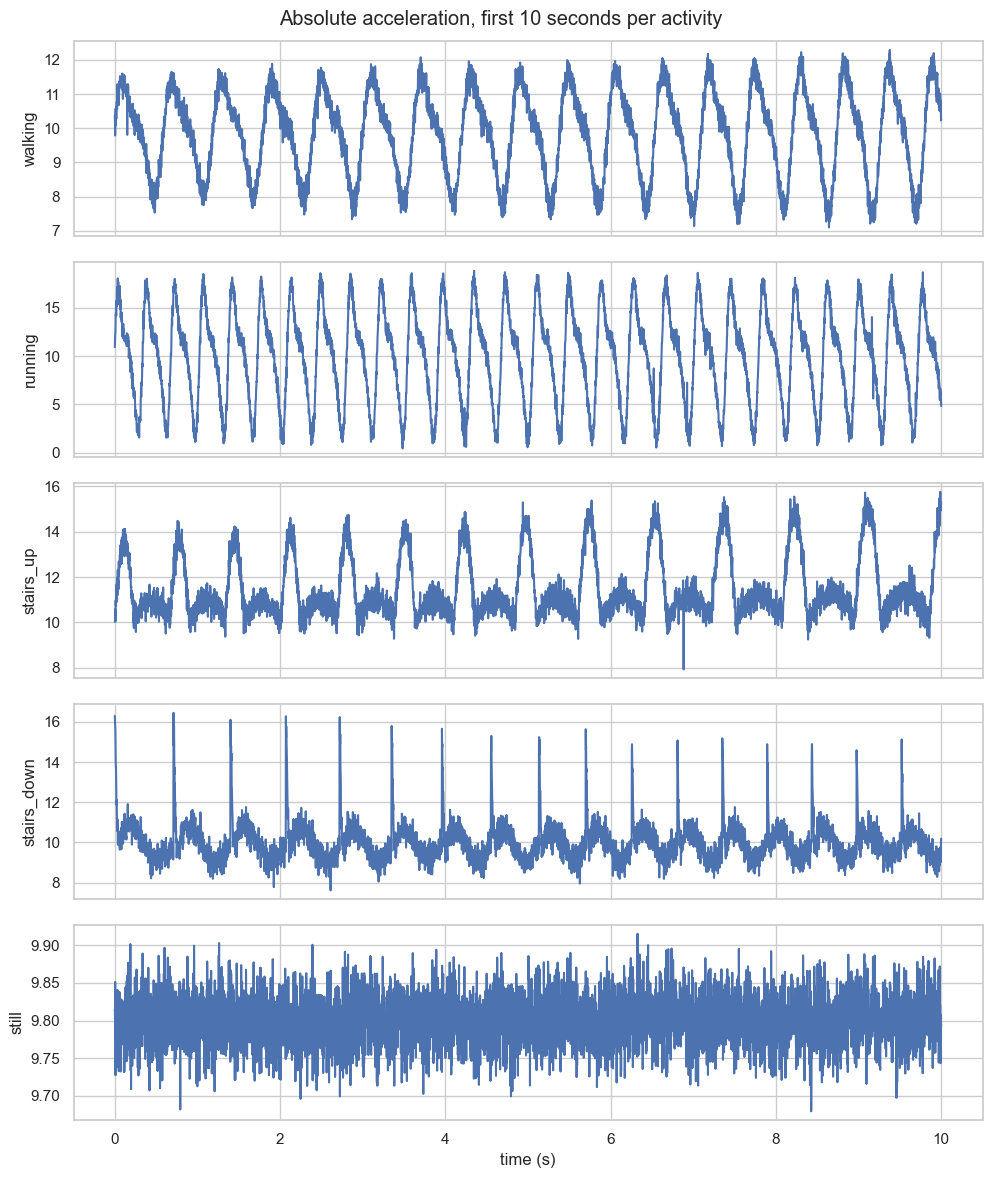

In [3]:
fig, axes = plt.subplots(len(recordings), 1, figsize=(10, 12), sharex=True)
for ax, (activity, recs) in zip(axes, recordings.items()):
    df = recs[0]
    mask = df["time"] - df["time"].iloc[0] <= 10
    ax.plot(df["time"][mask] - df["time"].iloc[0], df["mag"][mask])
    ax.set_ylabel(activity)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Absolute acceleration, first 10 seconds per activity")
plt.tight_layout()


## 2. Resample to a uniform rate

Phyphox's native sampling rate depends on the phone (~478 Hz measured on our
recordings) — every recording is resampled to a fixed 50 Hz grid via linear
interpolation (`har_common.resample_uniform`) before any feature is computed, so
recordings from different phones/teammates stay comparable.


Text(0.5, 1.0, 'Resampling sanity check (walking, first 3s)')

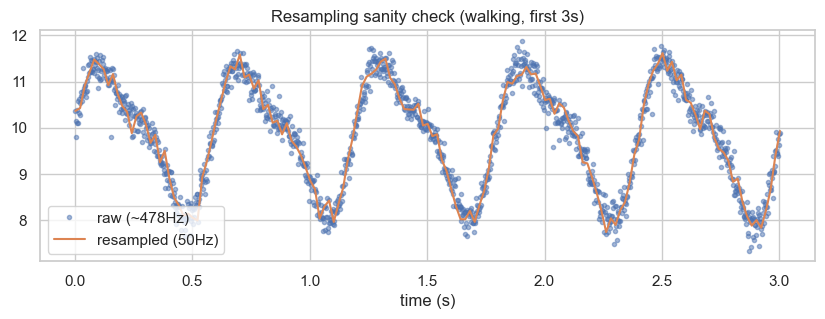

In [4]:
sample_raw = recordings["walking"][0]
sample_resampled = hc.resample_uniform(sample_raw)
fig, ax = plt.subplots(figsize=(10, 3))
mask_raw = sample_raw["time"] - sample_raw["time"].iloc[0] <= 3
mask_rs = sample_resampled["time"] - sample_resampled["time"].iloc[0] <= 3
ax.plot(sample_raw["time"][mask_raw], sample_raw["mag"][mask_raw], ".", label="raw (~478Hz)", alpha=0.5)
ax.plot(sample_resampled["time"][mask_rs], sample_resampled["mag"][mask_rs], "-", label="resampled (50Hz)")
ax.legend(); ax.set_xlabel("time (s)"); ax.set_title("Resampling sanity check (walking, first 3s)")


## 3. Handling phone orientation, *then* windowing + feature extraction

**Why this section exists:** an early version of this notebook used raw x/y/z
features directly. That failed badly — see the comparison below. Raw x/y/z encode
not just motion but *which way the phone is tilted*. Our five recordings were each
made with the phone held at one fixed (but different) orientation for the whole
5 minutes, so a classifier fed raw axes partly learns "which tilt = which
activity" instead of "what does this motion look like" — a shortcut that falls
apart the moment a test recording is held differently.


In [5]:
print("raw-axis means per activity (evidence of the orientation confound):")
for activity, recs in recordings.items():
    df = recs[0]
    print(f"{activity:12s}: x={df.x.mean():6.2f}  y={df.y.mean():6.2f}  z={df.z.mean():6.2f}")


raw-axis means per activity (evidence of the orientation confound):
walking     : x=  1.09  y=  1.89  z=  4.63
running     : x=  0.14  y= -3.97  z=  1.72
stairs_up   : x=  1.77  y=  4.37  z=  7.49
stairs_down : x= -0.89  y=  2.17  z=  5.68
still       : x=  0.91  y= -6.61  z=  4.22


Every activity has a *different* raw x/y/z mean — that's the phone's tilt for that
particular recording session, not a property of the activity. A model trained on
this directly would be learning orientation as much as motion.

**Fix:** decompose each sample into a gravity-aligned **vertical** component
(signed; gravity + true vertical acceleration) and a **horizontal** magnitude
(sideways/forward motion, with direction discarded since compass heading is
irrelevant to the activity). Gravity direction is estimated with a rolling
low-pass filter over the whole recording (`har_common.add_orientation_invariant_axes`),
so it adapts even if orientation drifts slowly within one continuous recording.
Together with the already-orientation-invariant magnitude, this replaces raw x/y/z
as the feature basis — the classifier now sees *how much you moved up-down* and
*how much you moved sideways*, regardless of how the phone was held.

Each recording is then split into 2.56s windows (128 samples @ 50Hz, the standard
UCI-HAR convention) with 50% overlap. Every window becomes one labeled sample
described by features per axis (vertical, horizontal, magnitude): mean, std,
min/max/range, RMS, mean absolute deviation, zero-crossing rate, signal magnitude
area, dominant FFT frequency, spectral energy — plus one vertical/horizontal
cross-correlation.


In [6]:
features_df = hc.build_training_table(recordings)
print(features_df.shape)
features_df.head()


(1165, 38)


,vertical_mean,vertical_std,vertical_min,vertical_max,vertical_range,vertical_rms,vertical_mad,vertical_zcr,vertical_sma,vertical_dom_freq,...,mag_mad,mag_zcr,mag_sma,mag_dom_freq,mag_spec_energy,corr_vert_horiz,window_start,window_end,slice_end,activity
0,9.875453,1.106312,7.729284,11.577980,3.848696,9.937228,0.951183,0.094488,9.875453,1.5625,...,0.957345,0.094488,9.909841,1.5625,79.675436,0.635508,0.00209,2.54209,1.28209,walking
1,9.850195,1.165420,7.603070,11.751397,4.148327,9.918899,1.002087,0.062992,9.850195,1.5625,...,1.008617,0.062992,9.888321,1.5625,88.497703,0.665180,1.28209,3.82209,2.56209,walking
2,9.825840,1.161718,7.507262,11.751397,4.244136,9.894277,0.984963,0.078740,9.825840,1.5625,...,0.995250,0.078740,9.867827,1.5625,88.442079,0.757042,2.56209,5.10209,3.84209,walking
3,9.770245,1.174203,7.507262,11.671362,4.164100,9.840551,1.003267,0.086614,9.770245,1.5625,...,1.015346,0.086614,9.815158,1.5625,90.516529,0.765315,3.84209,6.38209,5.12209,walking
4,9.649893,1.264621,7.584733,11.777511,4.192779,9.732404,1.105453,0.078740,9.649893,1.5625,...,1.119199,0.094488,9.697273,1.5625,105.146082,0.783299,5.12209,7.66209,6.40209,walking


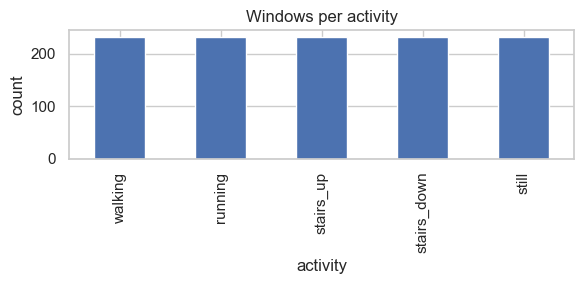

In [7]:
features_df["activity"].value_counts().plot(kind="bar", figsize=(6, 3), title="Windows per activity")
plt.ylabel("count"); plt.tight_layout()


### Feature separability

A 2D projection via matrix factorization (NMF) of the (non-negative-scaled) feature
matrix, colored by true activity, sanity-checks that the extracted features actually
separate the activities before we train anything.


Text(0, 0.5, 'component 2')

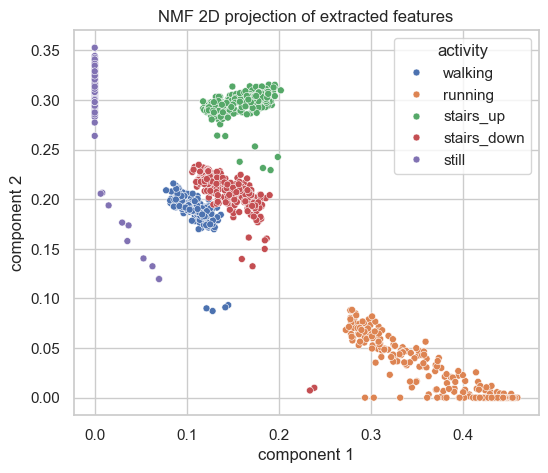

In [8]:
X_all = features_df[hc.FEATURE_NAMES]
X_nonneg = MinMaxScaler().fit_transform(X_all)
nmf = NMF(n_components=2, init="nndsvda", random_state=RANDOM_STATE, max_iter=500)
projection = nmf.fit_transform(X_nonneg)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=projection[:, 0], y=projection[:, 1], hue=features_df["activity"], s=25)
plt.title("NMF 2D projection of extracted features")
plt.xlabel("component 1"); plt.ylabel("component 2")


## 4. Clustering (k-means) — grouping activities with similar characteristics

Requirement: group activities with similar characteristics without using the labels.
We standardize the features, pick k via the elbow method / silhouette score, then
compare the unsupervised clusters against the true activity labels.


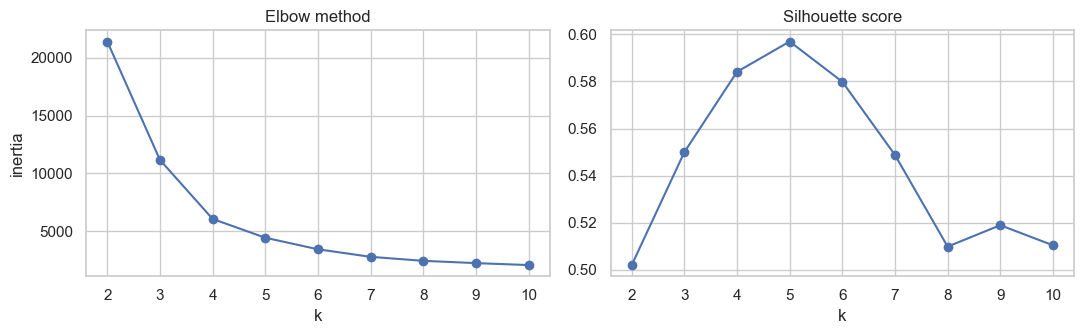

In [9]:
scaler = StandardScaler().fit(X_all)
X_scaled = scaler.transform(X_all)

inertias, silhouettes, ks = [], [], list(range(2, 11))
for k in ks:
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km_k.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ks, inertias, "o-"); axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[1].plot(ks, silhouettes, "o-"); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
plt.tight_layout()


In [10]:
N_CLUSTERS = len(hc.KNOWN_ACTIVITIES)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)

contingency = pd.crosstab(features_df["activity"], kmeans.labels_)
print(contingency)

cluster_to_activity = {}
for c in range(N_CLUSTERS):
    mask = kmeans.labels_ == c
    cluster_to_activity[c] = Counter(features_df["activity"].to_numpy()[mask]).most_common(1)[0][0]
print("cluster -> majority activity:", cluster_to_activity)


col_0          0    1    2    3    4
activity                            
running        0  233    0    0    0
stairs_down    0    1    0    0  232
stairs_up      0    0  232    0    1
still         10    0    0  223    0
walking      233    0    0    0    0
cluster -> majority activity: {0: 'walking', 1: 'running', 2: 'stairs_up', 3: 'still', 4: 'stairs_down'}


Note: unsupervised k-means with k=5 does not necessarily produce a 1:1 mapping onto
the 5 true activities — some clusters may share a majority label while another
activity gets none. That's an expected, honest result of unsupervised clustering
rather than a bug, and it's worth reporting rather than papered over.


### Reusing k-means as an unknown-activity detector

For every window we compute its distance to the nearest cluster centroid. Windows
from the training activities sit close to a centroid; a genuinely novel activity
should sit far from all of them. We set the rejection threshold at the 99th
percentile of in-training distances, then sanity-check it against a synthetic
signal that doesn't correspond to any trained activity (pure noise around 1g, no
periodic structure) — clearly a placeholder stand-in for a real held-out "unknown"
activity, which we don't have recorded yet.


unknown-distance threshold (99th percentile): 4.366709523590193
synthetic OOD windows flagged unknown: 100%


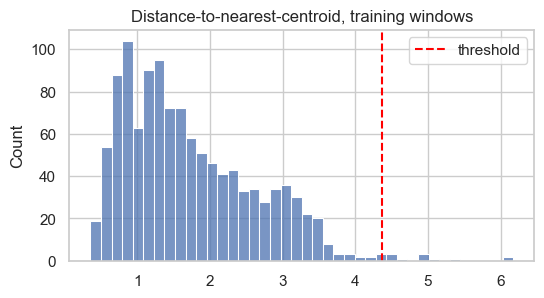

In [11]:
activities_arr = features_df["activity"].to_numpy()
_, train_dists = hc.unknown_distances(X_scaled, kmeans, cluster_to_activity)
UNKNOWN_THRESHOLD = hc.fit_unknown_threshold(X_scaled, activities_arr, kmeans, cluster_to_activity, percentile=99)
print("unknown-distance threshold (99th percentile):", UNKNOWN_THRESHOLD)

plt.figure(figsize=(6, 3))
sns.histplot(train_dists, bins=40)
plt.axvline(UNKNOWN_THRESHOLD, color="red", linestyle="--", label="threshold")
plt.legend(); plt.title("Distance-to-nearest-centroid, training windows")

# Synthetic sanity check: noise-only "activity", not one of our 5 trained classes
rng = np.random.default_rng(RANDOM_STATE)
n_synth = 500
synthetic_ood = pd.DataFrame({
    "time": np.arange(n_synth) / hc.TARGET_RATE_HZ,
    "x": rng.normal(0, 3, n_synth),
    "y": rng.normal(0, 3, n_synth),
    "z": rng.normal(9.8, 3, n_synth),
})
synthetic_ood["mag"] = np.sqrt(synthetic_ood.x**2 + synthetic_ood.y**2 + synthetic_ood.z**2)
synth_feats = hc.featurize_recording(synthetic_ood)
synth_scaled = scaler.transform(synth_feats[hc.FEATURE_NAMES])
_, synth_dists = hc.unknown_distances(synth_scaled, kmeans, cluster_to_activity)
print(f"synthetic OOD windows flagged unknown: {(synth_dists > UNKNOWN_THRESHOLD).mean() * 100:.0f}%")


## 5. Classification — baseline (only algorithms taught in the course)

The from-scratch ID3 decision tree and Naive Bayes classifier (`decision_tree.py`,
`naive_bayes.py`, carried over from an earlier assignment in this course) only
support categorical attributes — exact-value splits and lookups — so continuous
features are first quantile-discretized into 4 bins per feature (bin edges fit on
the training split only).


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, features_df["activity"], test_size=0.3, random_state=RANDOM_STATE, stratify=features_df["activity"]
)

bin_edges = hc.fit_discretizer(X_train)
train_rows = hc.apply_discretizer(X_train, bin_edges)
for row, label in zip(train_rows, y_train):
    row["activity"] = label
test_rows = hc.apply_discretizer(X_test, bin_edges)
attr_values = hc.discrete_attr_values()

tree = id3(train_rows, list(hc.FEATURE_NAMES), "activity", attr_values)
default_class = y_train.value_counts().idxmax()
dt_preds = [dt_predict(tree, row, default_class) for row in test_rows]

nb = NaiveBayes()
nb.fit(train_rows, list(hc.FEATURE_NAMES), "activity", attr_values)
nb_preds = [nb.predict(row) for row in test_rows]

print("ID3 decision tree accuracy:", accuracy_score(y_test, dt_preds))
print(classification_report(y_test, dt_preds))
print("Naive Bayes accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))


ID3 decision tree accuracy: 1.0
              precision    recall  f1-score   support

     running       1.00      1.00      1.00        70
 stairs_down       1.00      1.00      1.00        70
   stairs_up       1.00      1.00      1.00        70
       still       1.00      1.00      1.00        70
     walking       1.00      1.00      1.00        70

    accuracy                           1.00       350
   macro avg       1.00      1.00      1.00       350
weighted avg       1.00      1.00      1.00       350

Naive Bayes accuracy: 0.9971428571428571
              precision    recall  f1-score   support

     running       0.99      1.00      0.99        70
 stairs_down       1.00      0.99      0.99        70
   stairs_up       1.00      1.00      1.00        70
       still       1.00      1.00      1.00        70
     walking       1.00      1.00      1.00        70

    accuracy                           1.00       350
   macro avg       1.00      1.00      1.00       350
weig

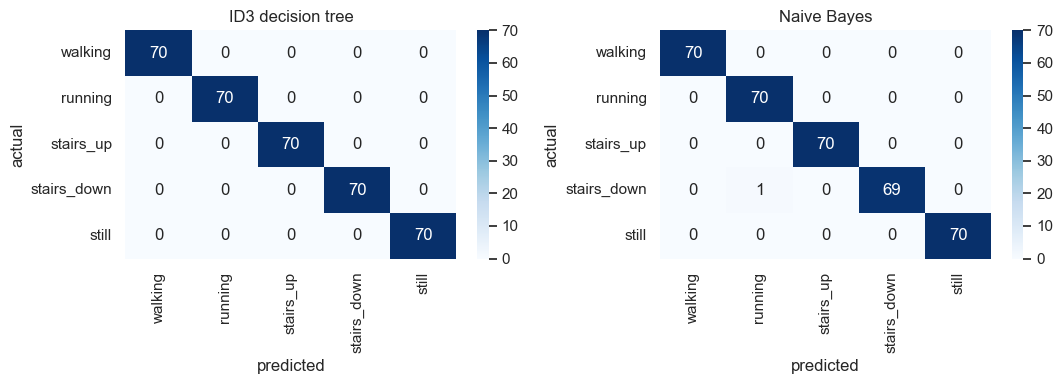

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(axes, [dt_preds, nb_preds], ["ID3 decision tree", "Naive Bayes"]):
    cm = confusion_matrix(y_test, preds, labels=hc.KNOWN_ACTIVITIES)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=hc.KNOWN_ACTIVITIES, yticklabels=hc.KNOWN_ACTIVITIES, ax=ax, cmap="Blues")
    ax.set_title(title); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout()


## 6. Classification — improved model

**Random Forest** — an ensemble of decision trees, the same family as the taught
ID3 algorithm, but it splits on continuous feature values directly (no
discretization needed), averages over many trees to reduce overfitting, and stays
explainable via `feature_importances_`. We use it as the production classifier in
the inference notebook.


Random Forest accuracy: 0.9942857142857143
              precision    recall  f1-score   support

     running       1.00      1.00      1.00        70
 stairs_down       1.00      1.00      1.00        70
   stairs_up       1.00      1.00      1.00        70
       still       1.00      0.97      0.99        70
     walking       0.97      1.00      0.99        70

    accuracy                           0.99       350
   macro avg       0.99      0.99      0.99       350
weighted avg       0.99      0.99      0.99       350



Text(29.609374999999993, 0.5, 'actual')

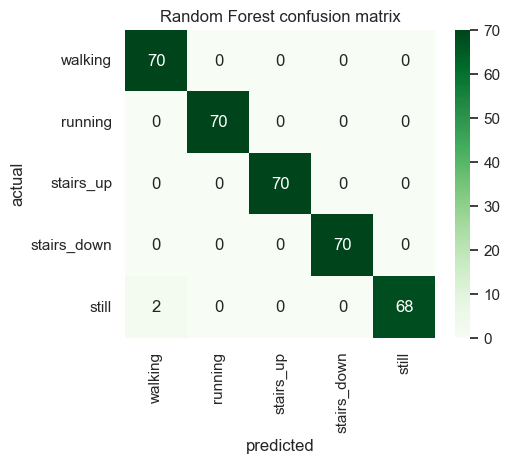

In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

cm = confusion_matrix(y_test, rf_preds, labels=hc.KNOWN_ACTIVITIES)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=hc.KNOWN_ACTIVITIES, yticklabels=hc.KNOWN_ACTIVITIES, cmap="Greens")
plt.title("Random Forest confusion matrix"); plt.xlabel("predicted"); plt.ylabel("actual")


                                model  accuracy
0          ID3 (taught-only baseline)  1.000000
1  Naive Bayes (taught-only baseline)  0.997143
2            Random Forest (improved)  0.994286


Text(0.5, 1.0, 'Random Forest — top 15 feature importances')

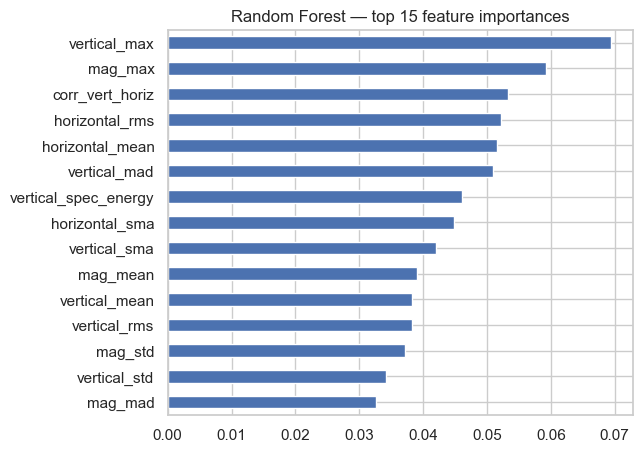

In [15]:
comparison = pd.DataFrame({
    "model": ["ID3 (taught-only baseline)", "Naive Bayes (taught-only baseline)", "Random Forest (improved)"],
    "accuracy": [accuracy_score(y_test, dt_preds), accuracy_score(y_test, nb_preds), accuracy_score(y_test, rf_preds)],
})
print(comparison)

importances = pd.Series(rf.feature_importances_, index=hc.FEATURE_NAMES).sort_values(ascending=False)
importances.head(15).plot(kind="barh", figsize=(6, 5)); plt.gca().invert_yaxis()
plt.title("Random Forest — top 15 feature importances")


## 7. Forecasting future signal behavior (Gaussian Process regression)

Requirement: predict the future behavior of the sensor signal. We fit a Gaussian
Process regressor (RBF kernel) to a windowed speed-proxy signal (rolling RMS of the
magnitude) for one activity and forecast a few seconds beyond the observed data,
with an uncertainty band.


Text(0.5, 1.0, 'Forecasting future signal behavior — running')

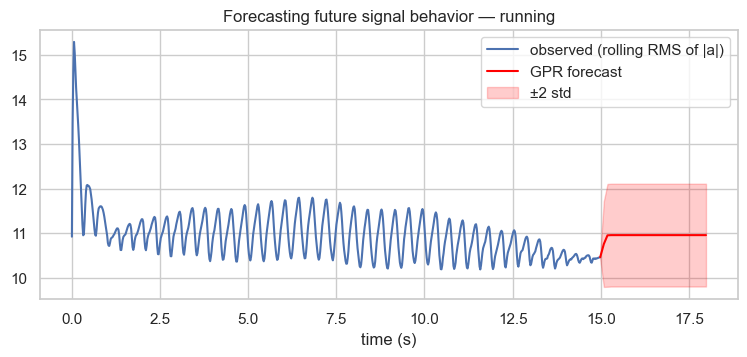

In [16]:
demo_df = hc.resample_uniform(recordings["running"][0])
proxy = demo_df["mag"].rolling(int(hc.TARGET_RATE_HZ), min_periods=1).apply(lambda w: np.sqrt(np.mean(w ** 2)))
segment = slice(0, int(15 * hc.TARGET_RATE_HZ))  # first 15 seconds
t_obs = demo_df["time"].to_numpy()[segment]
v_obs = proxy.to_numpy()[segment]

future_t, future_mean, future_std = hc.forecast_signal(t_obs, v_obs, horizon_sec=3, n_points=30)

plt.figure(figsize=(9, 3.5))
plt.plot(t_obs, v_obs, label="observed (rolling RMS of |a|)")
plt.plot(future_t, future_mean, color="red", label="GPR forecast")
plt.fill_between(future_t, future_mean - 2 * future_std, future_mean + 2 * future_std, color="red", alpha=0.2, label="±2 std")
plt.legend(); plt.xlabel("time (s)"); plt.title("Forecasting future signal behavior — running")


## 8. Persist trained artifacts for the inference notebook


In [17]:
artifacts = {
    "scaler": scaler,
    "random_forest": rf,
    "kmeans": kmeans,
    "cluster_to_activity": cluster_to_activity,
    "unknown_threshold": UNKNOWN_THRESHOLD,
    "bin_edges": bin_edges,   # kept for reference / reproducing the baseline model
    "decision_tree": tree,    # kept for reference / reproducing the baseline model
    "default_class": default_class,
}
hc.save_artifacts(artifacts)
print("saved to", hc.ARTIFACTS_DIR)


saved to /Users/dan/PycharmProjects/smart_agents_course_project_part_2 2/artifacts


## 9. Conclusions

- All three classifiers reach high held-out accuracy on this single-person dataset
  (see the comparison table above) — the extracted features clearly separate the
  five activities, confirming requirement 2 (unique per-activity patterns).
- **Orientation matters more than it looks.** A random train/test split accuracy
  number can look excellent (>98%) even with a model that partly learned "which
  way was the phone tilted" instead of "what does this motion look like" — because
  within one dataset, each activity happened to keep one fixed orientation for its
  whole recording. That shortcut only shows up as a failure on a *new* recording
  held differently, which is exactly why we moved to gravity-aligned
  vertical/horizontal features (section 3) instead of raw x/y/z.
- Unsupervised k-means (requirement 3) mostly recovers the true activities, but not
  as a clean 1:1 mapping — see the contingency table in section 4. This is
  expected: nothing forces an unsupervised method to align with our specific 5
  labels.
- The from-scratch, taught-only baseline (ID3 / Naive Bayes on discretized
  features) is compared directly against the improved Random Forest; Random
  Forest is used downstream because it handles continuous features natively and
  is at least as accurate.
- Gaussian Process regression forecasts short-horizon future signal behavior
  (requirement 5) and, reused as a least-squares trend-significance test, drives
  the Accelerate/Decelerate/Stable-speed remark in the inference notebook.
- **Caveats**: training data currently comes from a single 5-minute recording per
  activity from one team member. `har_common.load_activity_files` already
  supports multiple recordings per activity (e.g. `walking_2.csv`) — once
  teammates add their own recordings, just re-run this notebook to retrain on the
  combined data. The "Unknown" detector is only sanity-checked here against a
  synthetic noise signal; it should be re-validated once a real novel-activity
  recording is available.
